In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.e import Model_e
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
a = Model_e()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

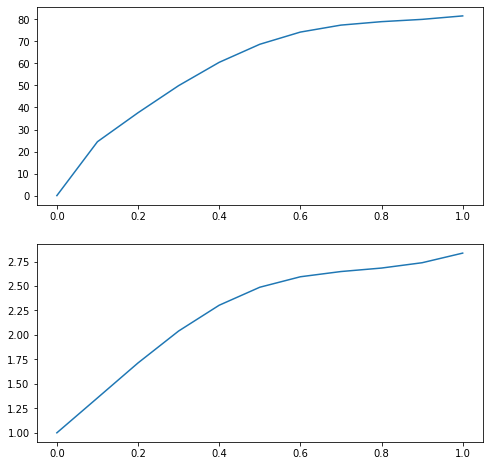

In [9]:
dur = 1.

a.params.duration = dur

target = a.getZeroTarget()
control1 = a.getZeroControl()
a.params.ext_exc_current = 2.

control1[0,0,:] += 2.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.rates_exc[:,:]

fig, axes = plt.subplots(2, figsize=(8, 8))
axes[0].plot(a.t, a.state["rates_exc"][0,:])
axes[1].plot(a.t, a.state["mufe"][0,:])
#axes[2].plot(simp.t, simp.state["tau_exc"][0,:])

In [30]:
max_cntrl = 10. * 5.
start_step = 10.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 100

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#0.7262797905237487

set cost params
RUN  0 , total integrated cost =  414.7933518318639
cost grad =  [[-34.95318204]]
phi =  34.95318204020139
cost grad shifted =  [[-35.062896]]
phi t+1=  35.062896001390875
cost grad =  [[-35.55730779]]
phi =  35.55730779131665
cost grad shifted =  [[-34.95318204]]
phi t+1=  34.95318204020139
cost grad =  [[-35.83407846]]
phi =  35.8340784619381
cost grad shifted =  [[-35.55730779]]
phi t+1=  35.55730779131665
cost grad =  [[-34.73498524]]
phi =  34.73498523944253
cost grad shifted =  [[-35.83407846]]
phi t+1=  35.8340784619381
cost grad =  [[-31.51973497]]
phi =  31.51973496506794
cost grad shifted =  [[-34.73498524]]
phi t+1=  34.73498523944253
cost grad =  [[-25.94577971]]
phi =  25.945779706260424
cost grad shifted =  [[-31.51973497]]
phi t+1=  31.51973496506794
cost grad =  [[-18.31640821]]
phi =  18.31640821335051
cost grad shifted =  [[-25.94577971]]
phi t+1=  25.945779706260424
cost grad =  [[-9.36188673]]
phi =  9.361886725356026
cost grad shifted =  [[-18.31640

RUN  9 , total integrated cost =  4.169541401355083
cost grad =  [[0.12067461]]
phi =  -0.12067460856164303
cost grad shifted =  [[-1.27503111]]
phi t+1=  1.2750311133692094
cost grad =  [[0.0790297]]
phi =  -0.07902969911194191
cost grad shifted =  [[0.12067461]]
phi t+1=  -0.12067460856164303
cost grad =  [[-0.36172997]]
phi =  0.3617299690290423
cost grad shifted =  [[0.0790297]]
phi t+1=  -0.07902969911194191
cost grad =  [[-0.69702955]]
phi =  0.697029553922917
cost grad shifted =  [[-0.36172997]]
phi t+1=  0.3617299690290423
cost grad =  [[-0.73753239]]
phi =  0.7375323850776709
cost grad shifted =  [[-0.69702955]]
phi t+1=  0.697029553922917
cost grad =  [[-0.49360721]]
phi =  0.4936072114712502
cost grad shifted =  [[-0.73753239]]
phi t+1=  0.7375323850776709
cost grad =  [[-0.10614131]]
phi =  0.10614131135164939
cost grad shifted =  [[-0.49360721]]
phi t+1=  0.4936072114712502
cost grad =  [[0.19075448]]
phi =  -0.1907544815499591
cost grad shifted =  [[-0.10614131]]
phi t+1=

cost grad shifted =  [[0.09120053]]
phi t+1=  -0.09120052634084885
cost grad =  [[0.]]
phi =  0.0
cost grad shifted =  [[0.]]
phi t+1=  0.0
RUN  16 , total integrated cost =  4.139551536913689
cost grad =  [[0.13446551]]
phi =  -0.1344655052395609
cost grad shifted =  [[-0.92500182]]
phi t+1=  0.9250018231457773
cost grad =  [[0.01162906]]
phi =  -0.011629063653074923
cost grad shifted =  [[0.13446551]]
phi t+1=  -0.1344655052395609
cost grad =  [[-0.30975566]]
phi =  0.3097556559955308
cost grad shifted =  [[0.01162906]]
phi t+1=  -0.011629063653074923
cost grad =  [[-0.50572878]]
phi =  0.5057287828107349
cost grad shifted =  [[-0.30975566]]
phi t+1=  0.3097556559955308
cost grad =  [[-0.50670098]]
phi =  0.5067009768570188
cost grad shifted =  [[-0.50572878]]
phi t+1=  0.5057287828107349
cost grad =  [[-0.34583186]]
phi =  0.3458318579296673
cost grad shifted =  [[-0.50670098]]
phi t+1=  0.5067009768570188
cost grad =  [[-0.10378031]]
phi =  0.1037803054260209
cost grad shifted =  [

RUN  27 , total integrated cost =  4.1311067348897845
cost grad =  [[-0.00403651]]
phi =  0.004036510939911864
cost grad shifted =  [[-0.80878475]]
phi t+1=  0.8087847451642602
cost grad =  [[-0.14659404]]
phi =  0.14659403503533497
cost grad shifted =  [[-0.00403651]]
phi t+1=  0.004036510939911864
cost grad =  [[-0.37816214]]
phi =  0.37816214475462573
cost grad shifted =  [[-0.14659404]]
phi t+1=  0.14659403503533497
cost grad =  [[-0.50127302]]
phi =  0.5012730190739916
cost grad shifted =  [[-0.37816214]]
phi t+1=  0.37816214475462573
cost grad =  [[-0.48654555]]
phi =  0.4865455515399759
cost grad shifted =  [[-0.50127302]]
phi t+1=  0.5012730190739916
cost grad =  [[-0.35561377]]
phi =  0.35561376833917535
cost grad shifted =  [[-0.48654555]]
phi t+1=  0.4865455515399759
cost grad =  [[-0.15910193]]
phi =  0.15910193415309948
cost grad shifted =  [[-0.35561377]]
phi t+1=  0.35561376833917535
cost grad =  [[0.0283922]]
phi =  -0.02839219817242622
cost grad shifted =  [[-0.1591019

cost grad =  [[-0.46450066]]
phi =  0.4645006600074737
cost grad shifted =  [[-0.35232664]]
phi t+1=  0.35232663559695254
cost grad =  [[-0.45658546]]
phi =  0.4565854646242826
cost grad shifted =  [[-0.46450066]]
phi t+1=  0.4645006600074737
cost grad =  [[-0.33747947]]
phi =  0.3374794666596017
cost grad shifted =  [[-0.45658546]]
phi t+1=  0.4565854646242826
cost grad =  [[-0.15346577]]
phi =  0.15346576679394275
cost grad shifted =  [[-0.33747947]]
phi t+1=  0.3374794666596017
cost grad =  [[0.02089739]]
phi =  -0.020897385562527404
cost grad shifted =  [[-0.15346577]]
phi t+1=  0.15346576679394275
cost grad =  [[0.]]
phi =  0.0
cost grad shifted =  [[0.02089739]]
phi t+1=  -0.020897385562527404
cost grad =  [[0.]]
phi =  0.0
cost grad shifted =  [[0.]]
phi t+1=  0.0
RUN  37 , total integrated cost =  4.129841561930489
cost grad =  [[-0.04173574]]
phi =  0.041735739429199725
cost grad shifted =  [[-0.73866238]]
phi t+1=  0.7386623835870694
cost grad =  [[-0.16886157]]
phi =  0.1688

RUN  46 , total integrated cost =  4.129578662535216
cost grad =  [[-0.07905453]]
phi =  0.07905453452458744
cost grad shifted =  [[-0.70072963]]
phi t+1=  0.7007296289763758
cost grad =  [[-0.17378985]]
phi =  0.17378985184831208
cost grad shifted =  [[-0.07905453]]
phi t+1=  0.07905453452458744
cost grad =  [[-0.35330823]]
phi =  0.3533082283117466
cost grad shifted =  [[-0.17378985]]
phi t+1=  0.17378985184831208
cost grad =  [[-0.46911511]]
phi =  0.46911511183596133
cost grad shifted =  [[-0.35330823]]
phi t+1=  0.3533082283117466
cost grad =  [[-0.46631991]]
phi =  0.4663199072912789
cost grad shifted =  [[-0.46911511]]
phi t+1=  0.46911511183596133
cost grad =  [[-0.34621279]]
phi =  0.3462127922071332
cost grad shifted =  [[-0.46631991]]
phi t+1=  0.4663199072912789
cost grad =  [[-0.15868894]]
phi =  0.15868894153633306
cost grad shifted =  [[-0.34621279]]
phi t+1=  0.3462127922071332
cost grad =  [[0.01390702]]
phi =  -0.013907015992870697
cost grad shifted =  [[-0.15868894]]

cost grad =  [[0.]]
phi =  0.0
cost grad shifted =  [[0.]]
phi t+1=  0.0
RUN  54 , total integrated cost =  4.129577793868025
cost grad =  [[-0.08073081]]
phi =  0.080730808257087
cost grad shifted =  [[-0.69984723]]
phi t+1=  0.6998472305375145
cost grad =  [[-0.17310076]]
phi =  0.17310076150695863
cost grad shifted =  [[-0.08073081]]
phi t+1=  0.080730808257087
cost grad =  [[-0.35317699]]
phi =  0.3531769891849166
cost grad shifted =  [[-0.17310076]]
phi t+1=  0.17310076150695863
cost grad =  [[-0.46939393]]
phi =  0.46939393357935444
cost grad shifted =  [[-0.35317699]]
phi t+1=  0.3531769891849166
cost grad =  [[-0.46641756]]
phi =  0.4664175632075427
cost grad shifted =  [[-0.46939393]]
phi t+1=  0.46939393357935444
cost grad =  [[-0.34618851]]
phi =  0.34618851477533497
cost grad shifted =  [[-0.46641756]]
phi t+1=  0.4664175632075427
cost grad =  [[-0.15865013]]
phi =  0.15865012931655542
cost grad shifted =  [[-0.34618851]]
phi t+1=  0.34618851477533497
cost grad =  [[0.01381

[[[0.         2.56881325 2.88404668 2.91316808 2.6270788  2.12458375
   1.57827123 1.17339165 1.03060094 1.03327725 0.        ]]]


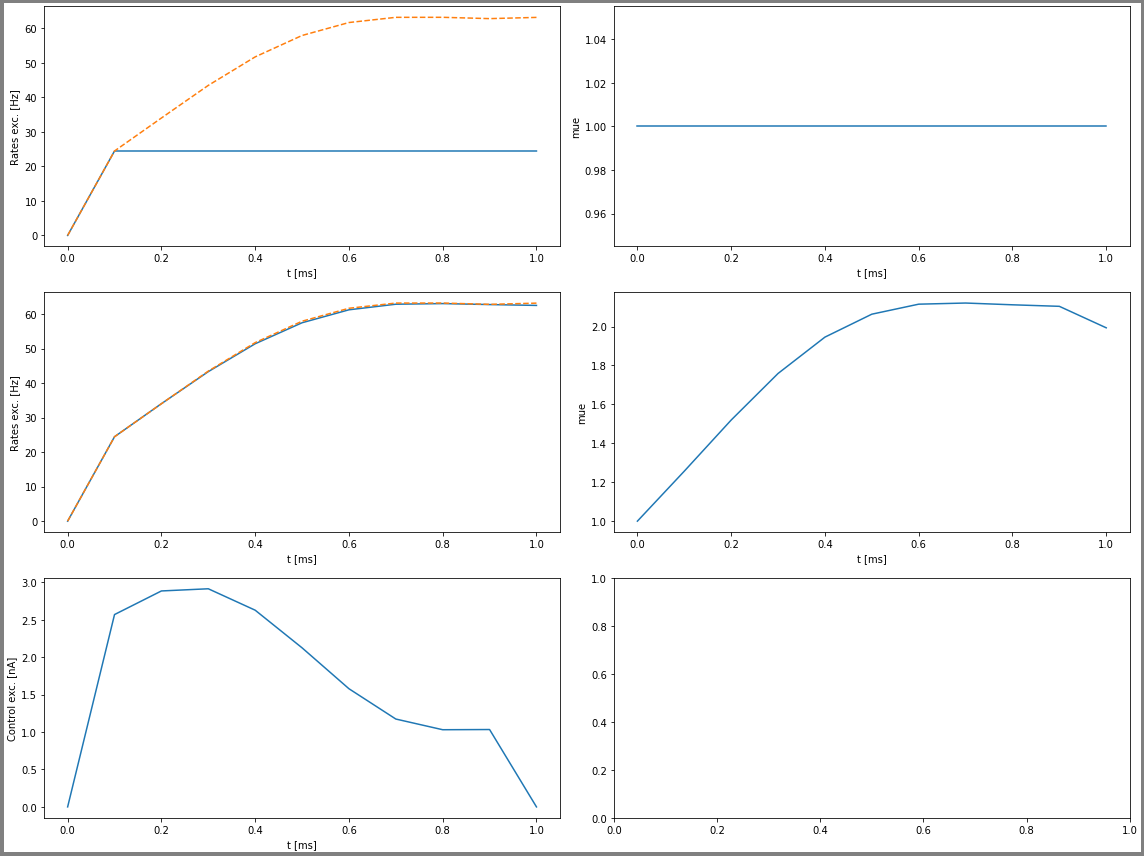

In [12]:
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [18]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 60

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  414.7933518318639
Using initial step.
RUN  1 , total integrated cost:  89.99436000372269
RUN  2 , total integrated cost:  13.09077132079518
RUN  3 , total integrated cost:  4.984646054535512
RUN  4 , total integrated cost:  4.46792260851522
RUN  5 , total integrated cost:  4.349012164926579
RUN  6 , total integrated cost:  4.241358170551288
RUN  7 , total integrated cost:  4.175314271560456
change helped, counter =  1
RUN  8 , total integrated cost:  4.145985039599028
RUN  9 , total integrated cost:  4.134582637663616
change helped, counter =  2
RUN  10 , total integrated cost:  4.130961599695227
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
change helped, counter =  3
RUN  11 , total integrated cost:  4.1299598784399185
change helped, counter =  2
change helped, counter =  4
RUN  12 , total integrated cost:  4.129723884391869
change helped, counter =  1
RUN  13 , total integrated cost:  4.12966427654

[[[0.         2.6103049  2.88990456 2.9152448  2.62805642 2.1266055
   1.5843756  1.18318006 1.03040251 0.99354861 0.        ]]]


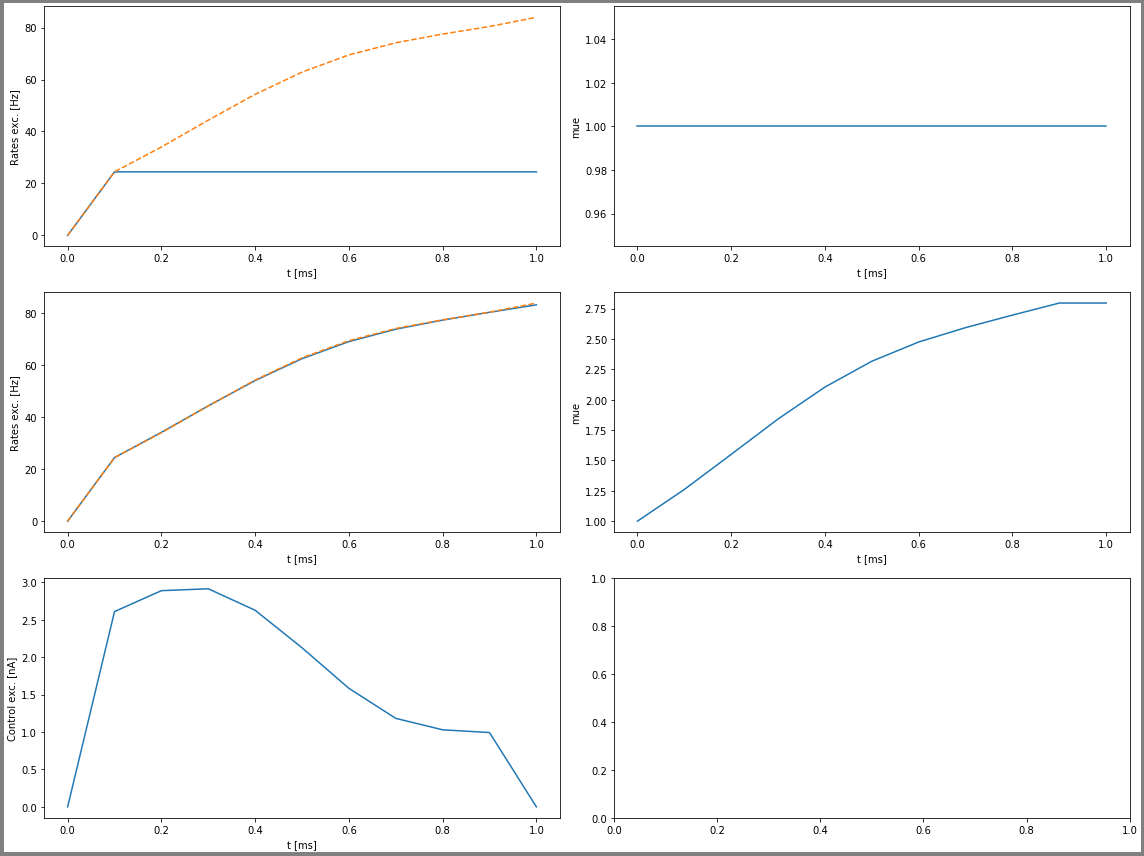

In [60]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

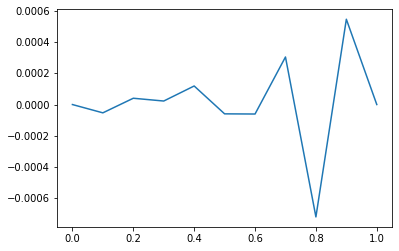

In [19]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


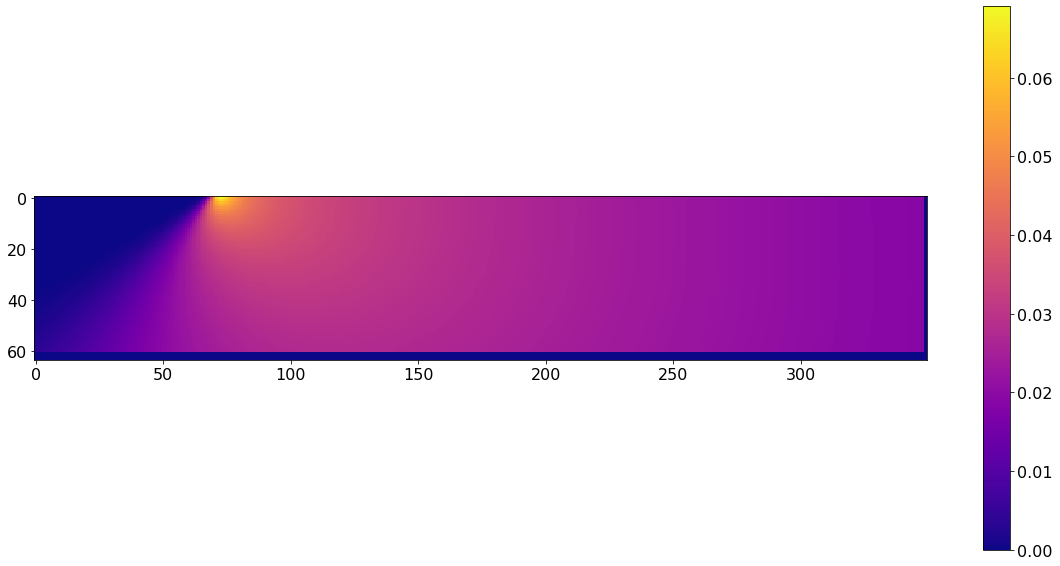

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


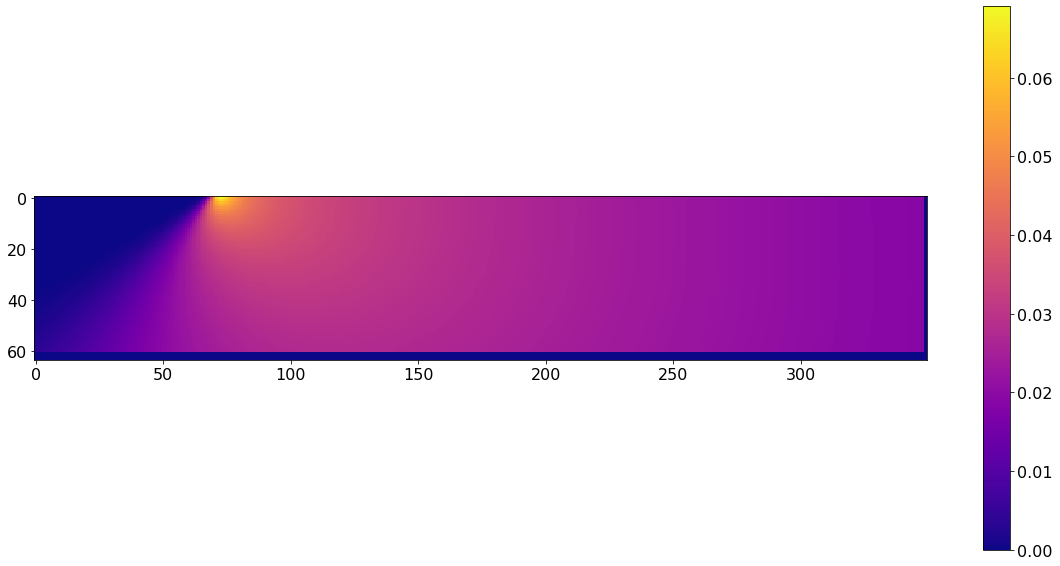

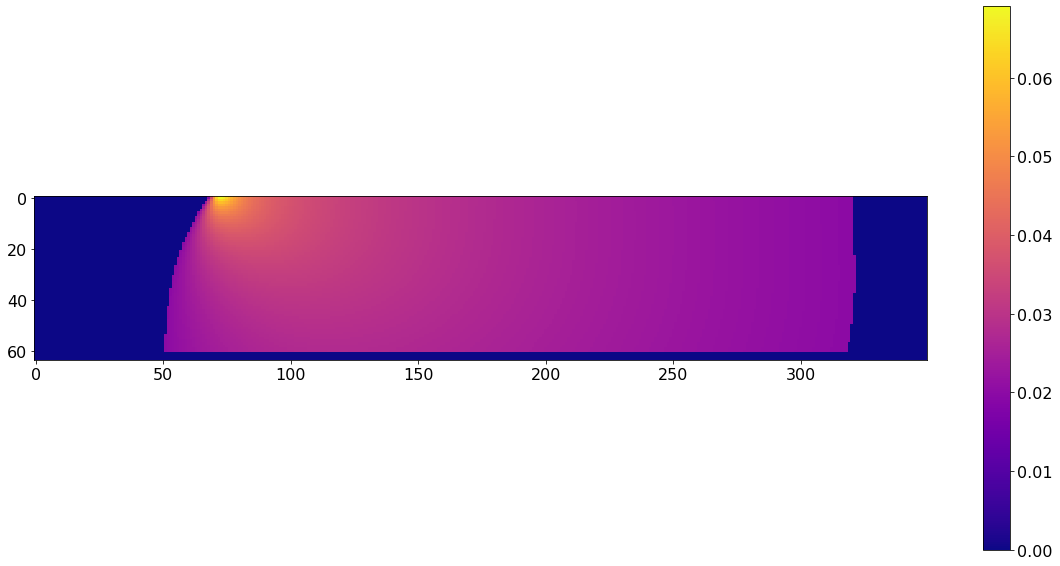

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()